In [4]:
import os
import json
from tqdm import tqdm
import pandas as pd

In [8]:
fastq = '/scratch/jplfaria/ReadMapping/data/10057.8.146725.CGCTCAT-GTACTGA.anqdpht.fastq'
index_sequences = {}
with open(fastq, 'r') as fh:
    pbar = tqdm(desc='!')
    line = fh.readline()
    #pbar.update()
    while line:
        if line[:8] == '@HISEQ15':
            _p = line.strip().split(':')
            index_sequence = _p[-1]
            if index_sequence not in index_sequences:
                index_sequences[index_sequence] = {
                    'count': 0,
                    'n_filtered': 0,
                    'y_filtered': 0
                }
            if _p[-3] == 'N':
                index_sequences[index_sequence]['n_filtered'] += 1
            else:
                index_sequences[index_sequence]['y_filtered'] += 1
            index_sequences[index_sequence]['count'] += 1
        line = fh.readline()
        #pbar.update()


!: 0it [00:00, ?it/s]

In [9]:
index_sequences

{'CGCTCATGTACTGA': {'count': 55027012,
  'n_filtered': 55027012,
  'y_filtered': 0}}

In [ ]:
coverm genome --interleaved /scratch/fliu/data/biodb/ncbi/sra/split3/SRR14857287_1.fastq 
--genome-fasta-files /scratch/fliu/data/ANME/IMG/IMG_2842053593/Ga0401164_contigs.fna 
-o /scratch/fliu/data/cliff/
--bam-file-cache-directory /scratch/fliu/data/cliff/reads/

In [10]:
!ls /scratch/fliu/data/cliff/

Cliff_310MAG_relabund.tsv	  genome_clusters_84_no_limit.json
all_prot.fna			  genome_clusters_95_no_limit.json
ani_mmseqs			  metadata_ani_g.json
annotation.json			  mmseqs
annotation_ani_prob.json	  mmseqs_ani_prob.json
annotation_ani_prob_gep_85.json   mmseqs_ani_prob_rep_genome.faa
annotation_ani_prob_lo_85.json	  mmseqs_ani_prob_rep_genome_v2.faa
core_data_comp.json		  mmseqs_ani_prob_v2.json
core_data_comp_70.json		  models
core_data_comp_84_no_limit.json   other
core_data_comp_85.json		  output
core_data_comp_95_no_limit.json   plots
db				  reads
genome_clusters.json		  sfaa.genome_feature_hash.json
genome_clusters_70.json		  super_faa.faa
genome_clusters_70_no_limit.json  super_model.json
genome_clusters_84.json


In [11]:
import json
with open('/home/fliu/cliff_mags/genome_h.json', 'r') as fh:
    metadata = json.load(fh)

In [13]:
!ls /home/fliu/scratch/data/kbase/cache/handle/KBH_5021275

/home/fliu/scratch/data/kbase/cache/handle/KBH_5021275


In [18]:
import os
fna_files = set()
for k, d in metadata.items():
    _h, _handle_id = d
    if not os.path.exists('/home/fliu/scratch/data/kbase/cache/handle/' + _handle_id):
        
        
        print(d)
    else:
        fna_files.add(_handle_id)

In [20]:
len(fna_files), len(metadata)

(450, 450)

In [ ]:
coverm genome --interleaved /scratch/jplfaria/ReadMapping/data/10057.8.146725.CGCTCAT-GTACTGA.anqdpht.fastq --genome-fasta-list /home/fliu/cliff_mags/ani_library.txt -o /scratch/fliu/data/cliff/reads/ani_library.out --bam-file-cache-directory /scratch/fliu/data/cliff/reads/

In [23]:
!ls /home/fliu/cliff_mags/

ANI.ipynb	   annotation.ipynb	      model_analysis-Copy1.ipynb
ani_graph.ipynb    checkm_summary_table.tsv   model_analysis.ipynb
ani_gtdb_gca.txt   core_reconstruction.ipynb  motu.ipynb
ani_gtdb_gca2.txt  data			      motu_model.ipynb
ani_gtdb_gcf.txt   genome_h.json	      pangenome_analysis.ipynb
ani_gtdb_gcf2.txt  groew.xlsx		      plot
ani_left_out.json  gtdb_table_arc.csv	      prob_model.ipynb
ani_library.txt    gtdb_table_bac.csv	      reads.ipynb
ani_self.txt	   mag_name_mapping.tsv       taxa_tree.json
ani_self2.txt	   metadata.tsv


In [32]:
!ls /scratch/fliu/data/biodb/ncbi/sra/

SRR14857287.fastq  SRR14857288.fastq.tar.gz  split3
SRR14857288.fastq  no_split


## Read sample read/assembly table
Build CoverM run scripts

In [5]:
path_reads = '/scratch/jplfaria/ReadMapping/data/'
path_metagenome_assembly = '/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/'
reads_fastq = set()
for f in os.listdir(path_reads):
    if f.endswith('.fastq'):
        reads_fastq.add(f)
found_metagenome_assembly = set()
for f in os.listdir(path_metagenome_assembly):
    if f.endswith('.fna.filtered.fa'):
        found_metagenome_assembly.add(f)

In [6]:
sample_data = pd.read_csv('/home/fliu/cliff_mags/data/sample_read_assembly.tsv', sep='\t', index_col=0).transpose().to_dict()

In [76]:
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id) and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
        
        bam_file_cache_directory = f"/scratch/fliu/data/cliff/reads/coverm/{sample_id}/"
        bam_file_cache_directory_bins = f"/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bam_bins/"
        bam_file_cache_directory_metagenome = f"/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bam_metagenome/"
        if not os.path.exists(bam_file_cache_directory):
            os.mkdir(bam_file_cache_directory)
            print(f'crated folder: {bam_file_cache_directory}')
        if not os.path.exists(bam_file_cache_directory_bins):
            os.mkdir(bam_file_cache_directory_bins)
            print(f'crated folder: {bam_file_cache_directory_bins}')
        if not os.path.exists(bam_file_cache_directory_metagenome):
            os.mkdir(bam_file_cache_directory_metagenome)
            print(f'crated folder: {bam_file_cache_directory_metagenome}')
        cmd_bins = [
            'coverm', 'genome', 
            '--interleaved', f'/scratch/jplfaria/ReadMapping/data/{read_id}',
            '--genome-fasta-list', '/home/fliu/cliff_mags/ani_library.txt',
            '-o', f'{bam_file_cache_directory}/coverm_bins.out',
            '--bam-file-cache-directory', bam_file_cache_directory_bins,
            
            '>',  f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/x.stdout',
            '2>', f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/x.stderr',
        ]
        cmd_metagenome = [
            'coverm', 'genome', 
            '--interleaved', f'/scratch/jplfaria/ReadMapping/data/{read_id}',
            '--genome-fasta-files', f'{path_metagenome_assembly}/{assembly_id}',
            '-o', f'{bam_file_cache_directory}/coverm_metagenome.out',
            '--bam-file-cache-directory', bam_file_cache_directory_metagenome,
            
            '>',  f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bins.stdout',
            '2>', f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bins.stderr',
        ]
        #print(sample_id, read_id, assembly_id)
        print(' '.join(cmd_bins))

coverm genome --interleaved /scratch/jplfaria/ReadMapping/data/10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq --genome-fasta-list /home/fliu/cliff_mags/ani_library.txt -o /scratch/fliu/data/cliff/reads/coverm/R1_A_D1_MG//coverm_bins.out --bam-file-cache-directory /scratch/fliu/data/cliff/reads/coverm/R1_A_D1_MG/bam_bins/ > /scratch/fliu/data/cliff/reads/coverm/R1_A_D1_MG/x.stdout 2> /scratch/fliu/data/cliff/reads/coverm/R1_A_D1_MG/x.stderr
coverm genome --interleaved /scratch/jplfaria/ReadMapping/data/10057.7.146718.ATTACTC-CCTATCC.anqdpht.fastq --genome-fasta-list /home/fliu/cliff_mags/ani_library.txt -o /scratch/fliu/data/cliff/reads/coverm/R1_A_D2_MG//coverm_bins.out --bam-file-cache-directory /scratch/fliu/data/cliff/reads/coverm/R1_A_D2_MG/bam_bins/ > /scratch/fliu/data/cliff/reads/coverm/R1_A_D2_MG/x.stdout 2> /scratch/fliu/data/cliff/reads/coverm/R1_A_D2_MG/x.stderr
coverm genome --interleaved /scratch/jplfaria/ReadMapping/data/10057.8.146725.ATTACTC-GGCTCTG.anqdpht.fastq --genome

In [33]:
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id) and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
        
        bam_file_cache_directory = f"/scratch/fliu/data/cliff/reads/coverm/{sample_id}/"
        bam_file_cache_directory_bins = f"/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bam_bins/"
        bam_file_cache_directory_metagenome = f"/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bam_metagenome/"
        
        if not os.path.exists(bam_file_cache_directory):
            os.mkdir(bam_file_cache_directory)
            print(f'crated folder: {bam_file_cache_directory}')
        if not os.path.exists(bam_file_cache_directory_bins):
            os.mkdir(bam_file_cache_directory_bins)
            print(f'crated folder: {bam_file_cache_directory_bins}')
        if not os.path.exists(bam_file_cache_directory_metagenome):
            os.mkdir(bam_file_cache_directory_metagenome)
            print(f'crated folder: {bam_file_cache_directory_metagenome}')
            
        outfile_bins = f'{bam_file_cache_directory}/coverm_bins.out'
        
        unammped_from_bins = None
        if os.path.exists(outfile_bins):
            unammped_from_bins = get_unmmapped_per(outfile_bins)
            
        if unammped_from_bins is None:
        
            cmd_bins = [
                'coverm', 'genome', 
                '--interleaved', f'/scratch/jplfaria/ReadMapping/data/{read_id}',
                '--genome-fasta-list', '/home/fliu/cliff_mags/ani_library.txt',
                '-o', f'{bam_file_cache_directory}/coverm_bins.out',
                '--bam-file-cache-directory', bam_file_cache_directory_bins,

                '>',  f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/output_bins.stdout',
                '2>', f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/output_bins.stderr',
            ]
            print(' '.join(cmd_bins))
            
        outfile_meta = f'{bam_file_cache_directory}/coverm_metagenome.out'
        unammped_from_meta = None
        if os.path.exists(outfile_meta):
            unammped_from_meta = get_unmmapped_per(outfile_meta)
            
        #print(sample_id, unammped_from_meta)
        if unammped_from_meta is None:
            
            cmd_metagenome = [
                'coverm', 'genome', 
                '--interleaved', f'/scratch/jplfaria/ReadMapping/data/{read_id}',
                '--genome-fasta-files', f'{path_metagenome_assembly}/{assembly_id}',
                '-o', f'{bam_file_cache_directory}/coverm_metagenome.out',
                '--bam-file-cache-directory', bam_file_cache_directory_metagenome,

                '>',  f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/output_meta.stdout',
                '2>', f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/output_meta.stderr',
            ]
            print(' '.join(cmd_metagenome))
        #print(sample_id, read_id, assembly_id)
        #print(' '.join(cmd_bins))

coverm genome --interleaved /scratch/jplfaria/ReadMapping/data/10092.3.148009.ATTACTC-CAGGACG.anqdpht.fastq --genome-fasta-files /scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies//185699.assembled.fna.filtered.fa -o /scratch/fliu/data/cliff/reads/coverm/R1_B_H2O_MG//coverm_metagenome.out --bam-file-cache-directory /scratch/fliu/data/cliff/reads/coverm/R1_B_H2O_MG/bam_metagenome/ > /scratch/fliu/data/cliff/reads/coverm/R1_B_H2O_MG/output_meta.stdout 2> /scratch/fliu/data/cliff/reads/coverm/R1_B_H2O_MG/output_meta.stderr
coverm genome --interleaved /scratch/jplfaria/ReadMapping/data/10057.6.146711.TCCGGAG-ATAGAGG.anqdpht.fastq --genome-fasta-list /home/fliu/cliff_mags/ani_library.txt -o /scratch/fliu/data/cliff/reads/coverm/R1_C_D2_MG//coverm_bins.out --bam-file-cache-directory /scratch/fliu/data/cliff/reads/coverm/R1_C_D2_MG/bam_bins/ > /scratch/fliu/data/cliff/reads/coverm/R1_C_D2_MG/output_bins.stdout 2> /scratch/fliu/data/cliff/reads/coverm/R1_C_D2_MG/output_bins.stder

In [42]:
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id) and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
        
        bam_file_cache_directory = f"/scratch/fliu/data/cliff/reads/coverm/{sample_id}/"
        bam_file_cache_directory_bins = f"/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bam_bins/"
        bam_file_cache_directory_metagenome = f"/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bam_metagenome/"
        
        if not os.path.exists(bam_file_cache_directory):
            os.mkdir(bam_file_cache_directory)
            print(f'crated folder: {bam_file_cache_directory}')
        if not os.path.exists(bam_file_cache_directory_bins):
            os.mkdir(bam_file_cache_directory_bins)
            print(f'crated folder: {bam_file_cache_directory_bins}')
        if not os.path.exists(bam_file_cache_directory_metagenome):
            os.mkdir(bam_file_cache_directory_metagenome)
            print(f'crated folder: {bam_file_cache_directory_metagenome}')
            
        outfile_bins = f'{bam_file_cache_directory}/coverm_bins.out'
        
        unammped_from_bins = None
        if os.path.exists(outfile_bins):
            unammped_from_bins = get_unmmapped_per(outfile_bins)
            
        outfile_meta = f'{bam_file_cache_directory}/coverm_metagenome.out'
        unammped_from_meta = None
        if os.path.exists(outfile_meta):
            unammped_from_meta = get_unmmapped_per(outfile_meta)
            
        print(sample_id, unammped_from_meta, unammped_from_bins)
        #print(' '.join(cmd_bins))

R1_A_D1_MG 41.87528 46.296394
R1_A_D2_MG 40.296555 44.013065
R1_A_H2O_MG 34.61766 70.01169
R1_B_D1_MG 51.379894 51.699852
R1_B_D2_MG 42.13673 43.792923
R1_B_H2O_MG 19.159954 50.455605
R1_C_D2_MG 54.66169 52.587605
R2_A_D1_MG 57.85991 66.47899
R2_B_D1_MG 68.951996 63.23668
R2_B_D2_MG 51.302135 57.111973
R2_B_H2O_MG 19.420523 47.69972
R2_C_D1_MG 56.13982 57.745106
R2_C_H2O_MG 15.581602 44.517838
R2_restored_C_black_MG 55.155678 57.0686
R2_restored_D_shore_MG 50.66166 68.436386
R2_restored_H2O_MG 7.202208 37.073677
R2A_A_D1_MG 86.84982 92.270424
R2A_A_D2_MG 90.00111 95.438934
R2A_A_H2O_MG 49.048615 70.42829
R2A_B_D1_MG 94.609055 95.43736
R2A_B_D2_MG 90.22718 93.505356
R2A_B_H2O_MG 54.691116 75.19718
R2A_C_D1_MG 81.84791 86.60599
R2A_C_D2_MG 65.69905 81.19473
R2A_C_H2O_MG 74.30837 84.370605
SF2_A_D2_MG 84.85237 89.096344
SF2_A_H2O_MG 76.88057 93.49438
SF2_B_D1_MG 87.7264 91.12267
SF2_B_D2_MG 88.7439 89.96052
SF2_B_H2O_MG 57.495354 89.36959
SF2_C_D1_MG 91.87343 92.765366
SF2_C_D2_MG 75.592 

In [39]:
def get_unmmapped_per(f):
    with open(f, 'r') as fh:
        _lines = fh.read().split('\n')
        if _lines is None or len(_lines) < 2:
            return None
        a, b = _lines[1].split()
        if a == 'unmapped':
            return b
    return None
#get_unmmapped_per(outfile_bins)

In [309]:
1

1

In [45]:
for k in found_metagenome_assembly:
    print(path_metagenome_assembly + k)

/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185694.assembled.fna.filtered.fa
/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185705.assembled.fna.filtered.fa
/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185704.assembled.fna.filtered.fa
/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185699.assembled.fna.filtered.fa
/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185720.assembled.fna.filtered.fa
/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185727.assembled.fna.filtered.fa
/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185707.assembled.fna.filtered.fa
/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185715.assembled.fna.filtered.fa
/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185701.assembled.fna.filtered.fa
/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/185718.assembled.fna.filtered.fa
/scratch/chenry/Proj

# mOTU-DB

`/home/fliu/python3/motus-tool` place with tools

`python motus.py downloadDB` to download the wierd DB

`python motus.py download -o mOTUv4.0_000793 -w mOTUv4.0_000793 -s mOTUv4.0_000793.metadata -r` to download their strange genome ids

In [46]:
!ls /scratch/shared/CDM/salterns/mOTUs-db-read-mapping/

10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq.motus
10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq.motus.bam
10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq.motus.mgc
10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq.motus.relab
10057.6.146711.CGCTCAT-ATAGAGG.anqdpht.fastq.motus
10057.6.146711.CGCTCAT-ATAGAGG.anqdpht.fastq.motus.bam
10057.6.146711.CGCTCAT-ATAGAGG.anqdpht.fastq.motus.mgc
10057.6.146711.CGCTCAT-ATAGAGG.anqdpht.fastq.motus.relab
10057.6.146711.CGCTCAT-TATAGCC.anqdpht.fastq.motus
10057.6.146711.CGCTCAT-TATAGCC.anqdpht.fastq.motus.bam
10057.6.146711.CGCTCAT-TATAGCC.anqdpht.fastq.motus.mgc
10057.6.146711.CGCTCAT-TATAGCC.anqdpht.fastq.motus.relab
10057.6.146711.TCCGGAG-ATAGAGG.anqdpht.fastq.motus
10057.6.146711.TCCGGAG-ATAGAGG.anqdpht.fastq.motus.bam
10057.6.146711.TCCGGAG-ATAGAGG.anqdpht.fastq.motus.mgc
10057.6.146711.TCCGGAG-ATAGAGG.anqdpht.fastq.motus.relab
10057.6.146711.TCCGGAG-CAGGACG.anqdpht.fastq.motus
10057.6.146711.TCCGGAG-CAGGACG.anqdpht.fastq.motus.bam
10057.6.146711.TCCGGAG

In [47]:
!head /scratch/shared/CDM/salterns/mOTUs-db-read-mapping/10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq.motus

#TOOL:4.0.0_DB:4.0	report_mode=counts	count_mode=INSERT_SCALED	min_mgcs=2
MOTU	unnamed sample
mOTUv4.0_000793	1
mOTUv4.0_001650	2
mOTUv4.0_002084	1
mOTUv4.0_002336	2
mOTUv4.0_003074	5
mOTUv4.0_003476	2
mOTUv4.0_004173	1
mOTUv4.0_004309	6


In [60]:
path = '/scratch/shared/CDM/salterns/mOTUs-db-read-mapping/'
all_motu_ids = set()
for f in os.listdir(path):
    if f.endswith('.fastq.motus'):
        motu_ids = set(pd.read_csv(f'{path}/{f}', sep='\t', skiprows=1, index_col=0).transpose().to_dict().keys())
        all_motu_ids |= motu_ids

In [66]:
with open('./mapped_motu_ids.txt', 'w') as fh:
    for k in all_motu_ids:
        fh.write(k + '\n')

In [98]:
from modelseedpy_ext.reads.reads_proc import _get_read_cov

In [ ]:
SF2_C_D1_MG	
10092.4.148015.ATTCAGA-CAGGACG.anqdpht.fastq.gz	
84518.assembled.fna	2	3300009145	
185729.assembled.fna	1	3300026099	started	started

In [107]:
bam_file_metagenome = '/home/fliu/cliff_mags/data/reads/coverm/SF2_C_D1_MG/bam_metagenome/coverm-genome.10092.4.148015.ATTCAGA-CAGGACG.anqdpht.fastq.bam'
bam_file_bins = '/home/fliu/cliff_mags/data/reads/coverm/SF2_C_D1_MG/bam_bins/coverm-genome.10092.4.148015.ATTCAGA-CAGGACG.anqdpht.fastq.bam'
bam_file_all_ma = '/home/fliu/cliff_mags/data/reads/coverm/SF2_C_D1_MG/bam_all_ma/coverm-genome.10092.4.148015.ATTCAGA-CAGGACG.anqdpht.fastq.bam'

In [110]:
import pysam
bam_data = {
    'metagenome': bam_file_metagenome, 
    'bins': bam_file_bins, 
    'all_metagenome': bam_file_all_ma,
}
block_data = {}
for k, f in bam_data.items():
    sam_file = pysam.AlignmentFile(f, "rb", index_filename=f + '.index')
    blocks = _get_read_cov(sam_file)
    block_data[k] = blocks

4437836it [01:14, 59356.44it/s] 
4036094it [01:15, 53551.88it/s] 
7883866it [06:43, 19556.65it/s]


In [109]:
def _get_read_cov(sam_file, save_seq=False):
    blocks_array = []
    for read in tqdm(sam_file.fetch()):
        blocks = read.get_blocks()

        if len(blocks) != 0:
            _block = [list(x) for x in blocks]
            _tags = [list(x) for x in read.tags]
            if save_seq:
                read_block = [read.qname, _block, _tags, read.is_paired, read.reference_name, read.seq]
            else:
                read_block = [read.qname, _block, _tags, read.is_paired, read.reference_name]
            blocks_array.append(read_block)
    return blocks_array



In [118]:
b_stat = {}
for b_id in block_data:
    blocks = block_data[b_id]
    for b in tqdm(blocks):
        if b[0] not in b_stat:
            b_stat[b[0]] = set()
        if b_id not in b_stat[b[0]]:
            b_stat[b[0]].add(b_id)
        else:
            pass
            #raise ValueError(f'{b_id} - {b[0]}')

100%|██████████| 7556373/7556373 [00:13<00:00, 559175.62it/s]


In [126]:
from collections import Counter
counter = Counter()
for k in tqdm(b_stat):
    counter.update(b_stat[k])

100%|██████████| 3988206/3988206 [00:08<00:00, 477843.35it/s]


In [127]:
counter

Counter({'bins': 2018047, 'all_metagenome': 3941933, 'metagenome': 2218918})

In [88]:
from tqdm import tqdm
for read in tqdm(sam_file.fetch()):
    if len(blocks) != 0:

0it [00:00, ?it/s]


In [95]:
blocks = read.get_blocks()

In [96]:
_block = [list(x) for x in blocks]
_tags = [list(x) for x in read.tags]

In [97]:
[read.qname, _block, _tags, read.is_paired, read.reference_name]

['HISEQ13:198:C8AJ6ANXX:4:2114:16906:17916',
 [[15, 165]],
 [['NM', 11], ['AS', 210]],
 True,
 '185729.assembled.fna.filtered~Ga0209920_1000001']

In [93]:
read.qname

'HISEQ13:198:C8AJ6ANXX:4:2114:16906:17916'

In [138]:
!head -n 20 /scratch/jplfaria/ReadMapping/data/10092.4.148015.ATTCAGA-CAGGACG.anqdpht.fastq

@HISEQ13:198:C8AJ6ANXX:4:1101:4579:3271 1:N:0:ATTCAGACAGGACG
ACGACCCCGTCCGGGGTTGCCGCGCCAGCCCAGGAAAAAACCCACCAGTTGCCACATGGCATCCAGGCCCAGGCAACCGGGCATGACCGGGTCCCCGGGAAAGTGGCACTGGAAAAACCACAGCTGCGGGTTGATATCCAACTCGGCGAC
+
3@B=AGGGGGGGGGFGGGGFBEGGGGGGGGGGGGGGGGGGFGGGGGGGGGGGGGGBGGGGGGGGGGGGGGGGGGGGGGGFGGGGGGGG;GGECGGGGGGGGGGGGGDGGGGGGGGGGGGGEGGGGBGGGBCCDGBGGGBEGGEGGGDDGD
@HISEQ13:198:C8AJ6ANXX:4:1101:4579:3271 2:N:0:ATTCAGACAGGACG
AGTCCTGCATGGTGTTGGGTAAGCGGCTGGCTTCAGGCTTGGAATTAATTTGCCGCTAGCGACACAACACTGGAATCTCTATGACTGGAAAGAACGCCTATAGCAAAGAAGAGCTGATCGCCTGTGGCAATGGTGAACTGTTCGGCCCGG
+
BBBCCGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGEEGGGGGGGGGGGGGGGGGGGGGGGGFGEGGGGGGGGGGGGGGGGGGGGGGGGADCGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGBGGGGGGG@@
@HISEQ13:198:C8AJ6ANXX:4:1101:4608:3311 1:N:0:ATTCAGACAGGACG
TCGCCTTCACGTCACGGACACTCGCGAAGACTAGCCCACTAAATTAACGTCTCAAAACCCACATGGGCGATGAATCAGGAGACGAGACAGCAATTAAGCTGCCAGTGCGTAACGAACGTCAGTGTCGGCGTTTGTTAGTGTTGGGCTTTT
+
3>BBAGGGEGGGGGBGGGG/EFGGGGFGGGGGGDGGGGDGGGGGGGGGGGGGGGGF

In [6]:
# modelseedpy_ext.reads.reads_proc::split_reads
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    if not pd.isna(read_id):
        read_id = read_id[:-3]
        filename_fastq = '/scratch/jplfaria/ReadMapping/data/' + read_id
        filename_fastq_1 = f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq'
        filename_fastq_2 = f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq'
        print(sample_id, read_id, filename_fastq)
        split_reads(filename_fastq, filename_fastq_1, filename_fastq_2)

R1_A_D1_MG 10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq /scratch/jplfaria/ReadMapping/data/10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq
R1_A_D2_MG 10057.7.146718.ATTACTC-CCTATCC.anqdpht.fastq /scratch/jplfaria/ReadMapping/data/10057.7.146718.ATTACTC-CCTATCC.anqdpht.fastq
R1_A_H2O_MG 10057.8.146725.ATTACTC-GGCTCTG.anqdpht.fastq /scratch/jplfaria/ReadMapping/data/10057.8.146725.ATTACTC-GGCTCTG.anqdpht.fastq
R1_B_D1_MG 10092.1.147996.ATTACTC-AGGCGAA.anqdpht.fastq /scratch/jplfaria/ReadMapping/data/10092.1.147996.ATTACTC-AGGCGAA.anqdpht.fastq
R1_B_D2_MG 10092.2.148003.ATTACTC-TAATCTT.anqdpht.fastq /scratch/jplfaria/ReadMapping/data/10092.2.148003.ATTACTC-TAATCTT.anqdpht.fastq
R1_B_H2O_MG 10092.3.148009.ATTACTC-CAGGACG.anqdpht.fastq /scratch/jplfaria/ReadMapping/data/10092.3.148009.ATTACTC-CAGGACG.anqdpht.fastq
R1_C_D2_MG 10057.6.146711.TCCGGAG-ATAGAGG.anqdpht.fastq /scratch/jplfaria/ReadMapping/data/10057.6.146711.TCCGGAG-ATAGAGG.anqdpht.fastq
R2_A_D1_MG 10057.7.146718.TCCGGAG-GGCTCTG.anqd

{1} 26035744
{2} 26035744


In [13]:
line_header

''

In [141]:
line_header, line_seq, line_sep, line_qua

('@HISEQ15:203:C7P4WANXX:6:1101:14855:2329 1:N:0:ATTACTCATAGAGG\n',
 'CAGACGCGCCGCAGCCAGGAGTTTTGCCTTGTTAATCAGGCCGTTGCGGACCGATTCGCCGCCCGCCCACTTCCCCCTTGACCCCGGGCGGCCGATTTCATACCTCACCCCCCTGCAAGGCGGGTATGGTGAAAAGGTATCACGCGAGCT\n',
 '+\n',
 'A>:?BGGGGGGGGGGGGFEGB=FGGGEGGGGGGGGGGGGGGFGGGGGGGGGGGGGDGGGBGGGGGGGGGGGEGGGGGGE@DGEGDGCDGGGGGG.C<.@DGGGGG/9DGGGGG.6D6/9CGC>>8C8@.8DD/86../88=BGBE>D###\n')

In [ ]:
line_header

In [ ]:

index_sequences = {}
with open(fastq, 'r') as fh:
    pbar = tqdm(desc='!')
    line = fh.readline()
    #pbar.update()
    while line:
        if line[:8] == '@HISEQ15':
            _p = line.strip().split(':')
            index_sequence = _p[-1]
            if index_sequence not in index_sequences:
                index_sequences[index_sequence] = {
                    'count': 0,
                    'n_filtered': 0,
                    'y_filtered': 0
                }
            if _p[-3] == 'N':
                index_sequences[index_sequence]['n_filtered'] += 1
            else:
                index_sequences[index_sequence]['y_filtered'] += 1
            index_sequences[index_sequence]['count'] += 1
        line = fh.readline()
        #pbar.update()

In [10]:
path = '/scratch/shared/CDM/salterns/mOTUs-db-read-mapping/'
all_motu_ids = set()
for f in os.listdir(path):
    if f.endswith('.fastq.motus'):
        print(f)
        motu_ids = set(pd.read_csv(f'{path}/{f}', sep='\t', skiprows=1, index_col=0).transpose().to_dict().keys())
        
        break

10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq.motus


In [35]:
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    if not pd.isna(read_id):
        read_id = read_id[:-3]
        file_fastq_motus = f'/scratch/shared/CDM/salterns/mOTUs-db-read-mapping/{read_id}.motus'
        if os.path.exists(file_fastq_motus):
            motu_ids = set(pd.read_csv(f'{path}/{f}', sep='\t', skiprows=1, index_col=0).transpose().to_dict().keys())
            print(sample_id, read_id)
            with open(f'/scratch/shared/CDM/salterns/mOTUs-db-sample-genome-files/{sample_id}.motus.genomes.txt', 'w') as fh:
                for motu_id in motu_ids:
                    if motu_id != 'mOTUv4.0_unassigned':
                        file_motu_genome_folder = f'/scratch/shared/CDM/salterns/mOTUs-db-all-matching-mOTUs/{motu_id}'
                        list_genome_files = get_genome_from_folder(file_motu_genome_folder)
                        for o in list_genome_files:
                            fh.write(o + '\n')

R1_A_D1_MG 10057.6.146711.ATTACTC-ATAGAGG.anqdpht.fastq
R1_A_D2_MG 10057.7.146718.ATTACTC-CCTATCC.anqdpht.fastq
R1_A_H2O_MG 10057.8.146725.ATTACTC-GGCTCTG.anqdpht.fastq
R1_B_D1_MG 10092.1.147996.ATTACTC-AGGCGAA.anqdpht.fastq
R1_B_D2_MG 10092.2.148003.ATTACTC-TAATCTT.anqdpht.fastq
R1_B_H2O_MG 10092.3.148009.ATTACTC-CAGGACG.anqdpht.fastq
R1_C_D2_MG 10057.6.146711.TCCGGAG-ATAGAGG.anqdpht.fastq
R2_A_D1_MG 10057.7.146718.TCCGGAG-GGCTCTG.anqdpht.fastq
R2_B_D1_MG 10057.6.146711.TCCGGAG-CAGGACG.anqdpht.fastq
R2_B_D2_MG 10092.3.148009.TCCGGAG-GTACTGA.anqdpht.fastq
R2_B_H2O_MG 10057.6.146711.CGCTCAT-TATAGCC.anqdpht.fastq
R2_C_D1_MG 10057.6.146711.CGCTCAT-ATAGAGG.anqdpht.fastq
R2_C_H2O_MG 10057.7.146718.CGCTCAT-GGCTCTG.anqdpht.fastq
R2_restored_C_black_MG 10057.7.146718.CGCTCAT-AGGCGAA.anqdpht.fastq
R2_restored_D_shore_MG 10057.7.146718.CGCTCAT-TAATCTT.anqdpht.fastq
R2_restored_H2O_MG 10057.8.146725.CGCTCAT-CAGGACG.anqdpht.fastq
R2A_A_D1_MG 10057.8.146725.CGCTCAT-GTACTGA.anqdpht.fastq
R2A_A_D2_MG

In [71]:
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id)  and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
            
        bam_file_cache_directory_bins_derep = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_derep/"
        bam_file_cache_directory_bins_rep = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_rep/"
        
        o_file_derep = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_derep/coverm.stderr'
        o_file_rep = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_rep/coverm.stderr'
        o_file_ext = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_exp/coverm.stderr'
        print(sample_id)
        print(done(o_file_derep))
        print(done(o_file_rep))
        print(done(o_file_ext))

R1_A_D1_MG
[2025-03-21T00:33:24Z INFO  coverm::genome] In sample 'R1_A_D1_MG_1.fastq', found 29516363 reads mapped out of 58003894 total (50.89%)
[2025-03-21T00:32:29Z INFO  coverm::genome] In sample 'R1_A_D1_MG_1.fastq', found 11844606 reads mapped out of 58003894 total (20.42%)
[2025-03-21T01:40:13Z INFO  coverm::genome] In sample 'R1_A_D1_MG_1.fastq', found 1086132 reads mapped out of 58003894 total (1.87%)
R1_A_D2_MG
[2025-03-21T00:33:36Z INFO  coverm::genome] In sample 'R1_A_D2_MG_1.fastq', found 30285096 reads mapped out of 57518286 total (52.65%)
[2025-03-21T00:32:40Z INFO  coverm::genome] In sample 'R1_A_D2_MG_1.fastq', found 14173705 reads mapped out of 57518286 total (24.64%)
[2025-03-21T01:41:03Z INFO  coverm::genome] In sample 'R1_A_D2_MG_1.fastq', found 931168 reads mapped out of 57518286 total (1.62%)
R1_A_H2O_MG
[2025-03-21T00:32:19Z INFO  coverm::genome] In sample 'R1_A_H2O_MG_1.fastq', found 15476912 reads mapped out of 53324324 total (29.02%)
[2025-03-21T00:31:45Z INF

In [41]:
def done(o_file):
    if os.path.exists(o_file):
        with open(o_file, 'r') as fh:
            _lines = fh.readlines()
            if 'reads mapped out of ' in _lines[-1]:
                return _lines[-1].strip()
    return False

!


In [66]:
cmds_derep = []
cmds_rep = []
cmds_ext = []

for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')



    if not pd.isna(read_id)  and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
        #print(sample_id, read_id, assembly_id)
        bam_file_cache_directory = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/"
        bam_file_cache_directory_bins = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins/"
        bam_file_cache_directory_metagenome = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/metagenome"
        bam_file_cache_directory_all_metagenome = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/all_metagenome"
        bam_file_cache_directory_motus = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/motus"

        bam_file_cache_directory_bins_derep = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_derep/"
        bam_file_cache_directory_bins_rep = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_rep/"
        bam_file_cache_directory_bins_exp = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_exp/"

        if not os.path.exists(bam_file_cache_directory):
            os.mkdir(bam_file_cache_directory)
            print(f'crated folder: {bam_file_cache_directory}')

        for p in [bam_file_cache_directory_bins, bam_file_cache_directory_metagenome, 
                  bam_file_cache_directory_all_metagenome, bam_file_cache_directory_motus,
                  bam_file_cache_directory_bins_derep, bam_file_cache_directory_bins_rep,
                  bam_file_cache_directory_bins_exp]:
            if not os.path.exists(p):
                os.mkdir(p)
                print(f'crated folder: {p}')
                
        cmd_bins_ext = [
            'coverm', 'genome', 
            '-1', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq',
            '-2', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq',
            '--genome-fasta-list', '/home/fliu/cliff_mags/data/ani_library_ext_mags.txt',
            '-t', '12',
            '-o', f'{bam_file_cache_directory_bins_exp}/coverm.o',
            '--bam-file-cache-directory', bam_file_cache_directory_bins_exp,

            '>',  f'{bam_file_cache_directory_bins_exp}/coverm.stdout',
            '2>', f'{bam_file_cache_directory_bins_exp}/coverm.stderr',
        ]
        cmds_ext.append(cmd_bins_ext)

        cmd_bins_derep = [
            'coverm', 'genome', 
            '-1', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq',
            '-2', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq',
            '--genome-fasta-list', '/home/fliu/cliff_mags/data/ani_library_derep_mags.txt',
            '-t', '12',
            '-o', f'{bam_file_cache_directory_bins_derep}/coverm.o',
            '--bam-file-cache-directory', bam_file_cache_directory_bins_derep,

            '>',  f'{bam_file_cache_directory_bins_derep}/coverm.stdout',
            '2>', f'{bam_file_cache_directory_bins_derep}/coverm.stderr',
        ]
        file_stderr_derep = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_derep/coverm.stderr'
        if done(file_stderr_derep) == False:
            cmds_derep.append(cmd_bins_derep)
            
        cmd_bins_rep = [
            'coverm', 'genome', 
            '-1', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq',
            '-2', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq',
            '--genome-fasta-list', '/home/fliu/cliff_mags/data/ani_library_rep_mags.txt',
            '-t', '12',
            '-o', f'{bam_file_cache_directory_bins_rep}/coverm.o',
            '--bam-file-cache-directory', bam_file_cache_directory_bins_rep,

            '>',  f'{bam_file_cache_directory_bins_rep}/coverm.stdout',
            '2>', f'{bam_file_cache_directory_bins_rep}/coverm.stderr',
        ]
        file_stderr_rep = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_rep/coverm.stderr'
        if done(file_stderr_rep) == False:
            cmds_rep.append(cmd_bins_rep)
        cmd_bins = [
            'coverm', 'genome', 
            '-1', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq',
            '-2', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq',
            '--genome-fasta-list', '/home/fliu/cliff_mags/ani_library.txt',
            '-t', '12',
            '-o', f'{bam_file_cache_directory_bins}/coverm.o',
            '--bam-file-cache-directory', bam_file_cache_directory_bins,

            '>',  f'{bam_file_cache_directory_bins}/coverm.stdout',
            '2>', f'{bam_file_cache_directory_bins}/coverm.stderr',
        ]
        cmd_motus = [
            'coverm', 'genome', 
            '-1', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq',
            '-2', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq',
            '--genome-fasta-list', f'/scratch/shared/CDM/salterns/mOTUs-db-sample-genome-files/{sample_id}.motus.genomes.txt',
            '-t', '12',
            '-o', f'{bam_file_cache_directory_motus}/coverm.o',
            '--bam-file-cache-directory', bam_file_cache_directory_motus,

            '>',  f'{bam_file_cache_directory_motus}/coverm.stdout',
            '2>', f'{bam_file_cache_directory_motus}/coverm.stderr',
        ]
        cmd_all_metagenome = [
            'coverm', 'genome', 
            '-1', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq',
            '-2', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq',
            '--genome-fasta-list', f'/home/fliu/cliff_mags/data/reads/metagenome_assembly.txt',
            '-t', '12',
            '-o', f'{bam_file_cache_directory_all_metagenome}/coverm.o',
            '--bam-file-cache-directory', bam_file_cache_directory_all_metagenome,

            '>',  f'{bam_file_cache_directory_all_metagenome}/coverm.stdout',
            '2>', f'{bam_file_cache_directory_all_metagenome}/coverm.stderr',
        ]
        cmd_metagenome = [
            'coverm', 'genome', 
            '-1', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq',
            '-2', f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq',
            '--genome-fasta-files', f'{path_metagenome_assembly}/{assembly_id}',
            '-t', '12',
            '-o', f'{bam_file_cache_directory_metagenome}/coverm.o',
            '--bam-file-cache-directory', bam_file_cache_directory_metagenome,

            '>',  f'{bam_file_cache_directory_metagenome}/coverm.stdout',
            '2>', f'{bam_file_cache_directory_metagenome}/coverm.stderr',
        ]
        with open(f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/run.sh', 'w') as fh:
            fh.write(' '.join(cmd_bins) + '\n')
            fh.write(' '.join(cmd_motus) + '\n')
            fh.write(' '.join(cmd_all_metagenome) + '\n')
            fh.write(' '.join(cmd_metagenome) + '\n')



In [67]:
len(cmds_derep), len(cmds_rep), len(cmd_bins_ext)

(0, 0, 18)

In [69]:
with open('/scratch/shared/CDM/salterns/reads/coverm/run_bins_ext.sh', 'w') as fh:
    for cmd_options in cmds_ext:
        cmd = ' '.join(cmd_options) + '\n'
        fh.write(cmd)

In [45]:
with open('/scratch/shared/CDM/salterns/reads/coverm/run_bins_derep.sh', 'w') as fh:
    for cmd_options in cmds_derep:
        cmd = ' '.join(cmd_options) + '\n'
        fh.write(cmd)
with open('/scratch/shared/CDM/salterns/reads/coverm/run_bins_rep.sh', 'w') as fh:
    for cmd_options in cmds_rep:
        cmd = ' '.join(cmd_options) + '\n'
        fh.write(cmd)

In [ ]:
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id)  and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
           
        bam_file_cache_directory = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/"
        bam_file_cache_directory_bins = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins/"
        bam_file_cache_directory_metagenome = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/metagenome"
        bam_file_cache_directory_all_metagenome = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/all_metagenome"
        bam_file_cache_directory_motus = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/motus"
        
        outfile_bins = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins/coverm.o'
        outfile_motus = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/motus/coverm.o'
        unammped_from_bins = None
        if os.path.exists(outfile_bins):
            unammped_from_bins = get_unmmapped_per(outfile_bins)
        
        unammped_from_metas = None
        if os.path.exists(outfile_motus):
            unammped_from_metas = get_unmmapped_per(outfile_motus)
        
        print(sample_id, unammped_from_bins, unammped_from_metas)

In [15]:
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id)  and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
           
        bam_file_cache_directory = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/"
        bam_file_cache_directory_bins = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins/"
        bam_file_cache_directory_metagenome = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/metagenome"
        bam_file_cache_directory_all_metagenome = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/all_metagenome"
        bam_file_cache_directory_motus = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/motus"
        
        outfile_bins = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins/coverm.o'
        outfile_motus = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/motus/coverm.o'
        

In [ ]:
'/scratch/shared/CDM/salterns/reads/coverm/R1_A_D1_MG/bins/coverm-genome.R1_A_D1_MG_1.fastq.bam'

In [16]:
import modelseedpy

modelseedpy 0.4.0


In [18]:
!ls /scratch/shared/CDM/salterns/analysis/maps/Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs/*.fasta

/scratch/shared/CDM/salterns/analysis/maps/Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs/Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs_reps.fasta


In [19]:
genome = modelseedpy.MSGenome.from_fasta('/scratch/shared/CDM/salterns/analysis/maps/Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs/Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs_reps.fasta')

In [23]:
!head /scratch/shared/CDM/salterns/analysis/maps/Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs/Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs_reps.fasta

>NODE_52_length_131214_cov_6.03563_1 # 3 # 527 # 1 # ID=1_1;partial=10;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.600
LLSTRGLARFPRLIAPFRRLMDILRAIPEIVVALVLIFILGGGPVPAMIAIALHTAGALGKLFSEVNENASLKPLEGLESVGASWSQRMLLGVVPQVAPNWLSYALLRFEINIRASAILGFVGSGGIGYDLKNAFSWGQGRYDEVAAIFILLFLTIVFFDQLSSHYRNKLIGKA*
>NODE_522_length_56948_cov_5.91947_51 # 54279 # 56948 # -1 # ID=14_51;partial=01;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.629
IEGVSEVATIGGMVKQHQVVVDPNKLRPFNIPLAKLRAAIGEANRESGGSVIEMAEAEYMVRATGYIDSIEDLAAIPLMINDRGAALTLEDVAEIRLGPQMRRGVGEFNGIGDAVGAVIVMRWGENALATINAVEEKLESLRASLPEGVEIVTTYDRSGVIERAIKNLQKKLTEEFIVVVLVCGAFLLHLRSSLVIVLFLPLGVLSAFAVMRLQGVNANIMSLGGIAIAIGAMVDAAVVMIEAMHRKMEGKRLTSEERWRAARDAAAEVGPALFYSLAIITVSFLPVFVLEAQEGRLFKPLAFTKTYAMGAAAILSVTLVPVLMGYFVRGRIVAERRNPLNVACQWMYRPFLDAAVAWPWATVLLAVALVASMAHPLQRLGTEFMPELNEGDFLYMPSLYPGVSIGKAREVLQQTNRMIKQVPEVKTVHGKLGRADTATDPAPLTMIETTIQLKDRDDWRPGVTMEDIRHELDARVQVPGVTNVWIQPIKNRIDMLATGIKTPVGVKVSGADLNVIEEIAVAVEQAVADIPGTASAYAERPVGGRFIEID

In [25]:
genome_kbase = kbase.get_from_ws('Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs__.RAST', 155805)

In [26]:
len(genome_kbase.features)

3325

In [22]:
for f in genome.features:
    print(f.id)

NODE_52_length_131214_cov_6.03563_1
NODE_522_length_56948_cov_5.91947_51
NODE_1413_length_32741_cov_5.22736_10
NODE_1476_length_31882_cov_6.03798_10
NODE_1519_length_31332_cov_6.35075_14
NODE_3518_length_17481_cov_5.31134_2
NODE_3953_length_16134_cov_4.21303_3
NODE_7455_length_10044_cov_5.01129_9
NODE_11217_length_7372_cov_5.80704_1
NODE_13009_length_6561_cov_7.38157_9
NODE_33417_length_3425_cov_5.26016_3
NODE_40114_length_3046_cov_1.26721_1
NODE_342_length_61052_cov_4.36187_62
NODE_668_length_40043_cov_3.00531_1
NODE_696_length_39080_cov_4.38482_27
NODE_1322_length_26309_cov_3.91521_28
NODE_1395_length_25386_cov_5.25345_10
NODE_2001_length_19793_cov_2.92057_1
NODE_2140_length_18758_cov_2.91691_1
NODE_2772_length_15625_cov_3.26952_15
NODE_2964_length_14880_cov_2.80431_1
NODE_4978_length_10356_cov_5.55695_3
NODE_5045_length_10257_cov_3.78312_9
NODE_6108_length_8905_cov_2.82331_9
NODE_10383_length_6097_cov_2.54171_5
NODE_15354_length_4599_cov_3.32245_3
NODE_22575_length_3502_cov_1.99822_

# KBase 

In [73]:
import cobrakbase
from tqdm import tqdm
from modelseedpy_ext.re.core.genome import REAssembly
import json
kbase = cobrakbase.KBaseCache(path='/scratch/fliu/data/kbase/cache/')

modelseedpy 0.4.0
cobrakbase 0.4.0


In [34]:
from modelseedpy import MSGenome
from modelseedpy_ext.re.hash_seq import HashSeq
proteins = {}
ct = 0
_path = '/scratch/shared/CDM/salterns/data/All_MAGs_proteins'
for f in os.listdir(_path):
    if f.startswith('Salt_') and f.endswith('.faa'):
        genome = MSGenome.from_fasta(_path + '/' + f)
        for f in genome.features:
            ct += 1
            h = HashSeq(f.seq).hash_value
            if h not in proteins:
                proteins[h] = f.seq

In [36]:
len(proteins), ct

(1283486, 1469007)

In [51]:
for ws_id in [155805, 163264]:
    infos = kbase.list_workspace(ws_id)
    for info in tqdm(infos):
        if info.type == 'KBaseGenomes.Genome':
            genome = kbase.get_from_ws(str(info))
            for f in genome.features:
                ct += 1
                h = HashSeq(f.seq).hash_value
                if h not in proteins:
                    proteins[h] = f.seq

100%|██████████| 283/283 [03:03<00:00,  1.54it/s] 


In [74]:
f_to_h = {}
with open('./ani_library.txt', 'r') as fh:
    l = fh.readline().strip()
    while l:
        re_assembly = REAssembly.from_fasta(l)
        _h = re_assembly.hash_value
        f_to_h[l] = _h
        l = fh.readline().strip()

In [75]:
d_handle_to_genome_id = {}
d_genome_to_assembly_h = {}
d_fasta_to_assembly_h = {}
d_info_to_assembly_h = {}
for ws_id in [163264, 155805]:
    infos = kbase.list_workspace(ws_id)
    for info in tqdm(infos):
        if info.type == 'KBaseGenomes.Genome':
            genome = kbase.get_from_ws(str(info))
            assembly = kbase.get_from_ws(genome.assembly_ref)
            handle_ref = assembly.fasta_handle_ref
            fasta_file = f'/scratch/fliu/data/kbase/cache/handle/{assembly.fasta_handle_ref}'
            if os.path.exists(fasta_file):
                re_assembly = REAssembly.from_fasta(fasta_file)
                d_genome_to_assembly_h[info.id] = re_assembly.hash_value
                d_fasta_to_assembly_h[fasta_file] = re_assembly.hash_value
                d_info_to_assembly_h[str(info)] = re_assembly.hash_value
            else:
                raise ValueError(ws_id, info.id, handle_ref)
            if handle_ref not in d_handle_to_genome_id:
                d_handle_to_genome_id[handle_ref] = info.id
            else:
                raise ValueError(ws_id, info.id, handle_ref)

100%|██████████| 1298/1298 [02:53<00:00,  7.49it/s] 


In [76]:
def get_genome_id_from_handle(i):
    c = set()
    for k, v in d_genome_to_assembly_h.items():
        if v == f_to_h['/scratch/fliu/data/kbase/cache/handle/' + i]:
            c.add(k)
    if len(c) == 1:
        return list(c)[0]
    else:
        raise ValueError('!')
def get_genome_ref_from_handle(i):
    c = set()
    for k, v in d_info_to_assembly_h.items():
        if v == f_to_h['/scratch/fliu/data/kbase/cache/handle/' + i]:
            c.add(k)
    if len(c) == 1:
        return list(c)[0]
    else:
        raise ValueError('!')

In [81]:
ani_handle_to_genome = {}
with open('./ani_library.txt', 'r') as fh:
    l = fh.readline().strip()
    while l:
        handle_ref = l.split('/')[-1]
        ani_handle_to_genome[handle_ref] = {
            'genome_id': get_genome_id_from_handle(handle_ref),
            'genome_ref': get_genome_ref_from_handle(handle_ref),
            'filename_fasta': l
        }
        l = fh.readline().strip()

In [82]:
with open('./data/metadata_handle_ref.json', 'w') as fh:
    fh.write(json.dumps(ani_handle_to_genome))

In [52]:
len(proteins), ct

(2544318, 3025473)

In [49]:
a = set()
for info in tqdm(infos):
    if info.type == 'KBaseGenomes.Genome':
        a.add(info.id)
        print(info.id, info.type)

100%|██████████| 1298/1298 [00:00<00:00, 266077.25it/s]

Salt_Pond_MetaGSF2_B_H2O_MG_DASTool_bins_metabat.8.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.4.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R2_restored_DShore_MG_DASTool_bins_concoct_out.46.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_concoct_out.21.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R2_A_H2O_MG_DASTool_bins_concoct_out.29.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.50.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.18.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaGSF2_C_D2_MG_DASTool_bins_concoct_out.32.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.15.contigs__.RAST KBaseGenomes.Genome
Salt_Pond_MetaG_R2_C_D1

# Read CoverM results

In [8]:
import json
import pandas as pd
import os

In [9]:
sample_data = pd.read_csv(
    '/home/fliu/cliff_mags/data/sample_read_assembly.tsv', 
    sep='\t', index_col=0).transpose().to_dict()
path_reads = '/scratch/jplfaria/ReadMapping/data/'
path_metagenome_assembly = '/scratch/chenry/Projects/Salterns/nboutput/metagenome_assemblies/'
reads_fastq = set()
for f in os.listdir(path_reads):
    if f.endswith('.fastq'):
        reads_fastq.add(f)
found_metagenome_assembly = set()
for f in os.listdir(path_metagenome_assembly):
    if f.endswith('.fna.filtered.fa'):
        found_metagenome_assembly.add(f)

In [10]:
metadata_handle_ref = None
with open('./data/metadata_handle_ref.json', 'r') as fh:
    metadata_handle_ref = json.load(fh)

In [12]:
def read_and_translate(filename_coverm_out, translate):
    res = {}
    with open(filename_coverm_out, 'r') as fh:
        l = fh.readline()
        while l:
            l = fh.readline().strip()
            if l:
                genome, mapped_frac = l.strip().split('\t')
                if genome != 'unmapped':
                    genome = translate[genome]['genome_id']
                res[genome] = float(mapped_frac)
    return res

In [14]:
sample_to_coverm_results = {}
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id) and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
        
        outfile_bins = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins/coverm.o'
        coverm_out = read_and_translate(outfile_bins, metadata_handle_ref)
        sample_to_coverm_results[sample_id] = coverm_out

# Generate BAM index files

In [80]:
import glob
folder = '/scratch/shared/CDM/salterns/reads/coverm/'
with open('/scratch/shared/CDM/salterns/reads/coverm/run_samtools_index.sh', 'w') as fh:
    for filename in glob.iglob(folder + '**/*.bam', recursive=True):
        filename_index = filename + '.index'
        if not os.path.exists(filename_index):
            cmd = [
                '/opt/samtools/samtools', 'index',
                filename,
                '-o', filename_index
            ]
            fh.write(' '.join(cmd) + '\n')

In [118]:
folder = '/scratch/shared/CDM/salterns/reads/coverm/'
for filename in glob.iglob(folder + '**/*.bam', recursive=True):
    filename_index = filename + '.index'
    if not os.path.exists(filename_index):
        print(filename)

# Read BAM cov

In [76]:
import pysam
from tqdm import tqdm
def get_reads_mapped(sam):
    reads_mapped = {}
    for read in tqdm(sam.fetch()):
        blocks = read.get_blocks()
        if len(blocks) != 0:
            if read.qname not in reads_mapped:
                reads_mapped[read.qname] = []
            reads_mapped[read.qname].append(read)
    return reads_mapped
sample_id = 'R1_A_D1_MG'


In [304]:
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id) and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
            
        output_cov_path = f'/scratch/shared/CDM/salterns/reads/cov/{sample_id}/'
        if not os.path.exists(output_cov_path):
            os.mkdir(output_cov_path)
            print(f'crated folder: {output_cov_path}')

In [312]:
skip = {'R1_A_D1_MG', 'R1_A_D2_MG', 'R1_A_H2O_MG'}

In [ ]:

for sample_id in sample_data:
    read_set_genomes = {
            'derep': '/home/fliu/cliff_mags/data/ani_library_derep_mags.txt',
            'rep': '/home/fliu/cliff_mags/data/ani_library_rep_mags.txt',
            'ext': '/home/fliu/cliff_mags/data/ani_library_ext_mags.txt',
    'motu': f'/scratch/shared/CDM/salterns/mOTUs-db-sample-genome-files/{sample_id}.motus.genomes.txt'
        }
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id) and not pd.isna(assembly_id) and sample_id not in skip:
        print(sample_id)
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
            
        output_cov_path = f'/scratch/shared/CDM/salterns/reads/cov/{sample_id}/'
        if not os.path.exists(output_cov_path):
            os.mkdir(output_cov_path)
            print(f'crated folder: {output_cov_path}')
            
        filename_bam_derep = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_derep/coverm-genome.{sample_id}_1.fastq.bam'
        filename_bam_rep = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_rep/coverm-genome.{sample_id}_1.fastq.bam'
        filename_bam_ext = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_exp/coverm-genome.{sample_id}_1.fastq.bam'
        filename_bam_motu = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/motus/coverm-genome.{sample_id}_1.fastq.bam'
        
        bams = {
            'derep': filename_bam_derep,
            'rep': filename_bam_rep,
            'ext': filename_bam_ext,
            #'motu': filename_bam_motu
        }
        mapped_reads = {}
        for k, filename_bam in bams.items():
            print(filename_bam)
            sam = pysam.AlignmentFile(filename_bam, "rb", index_filename=filename_bam + '.index')
            mapped_reads[k] = get_reads_mapped(sam)

        reads_shared_group = {}
        for k in mapped_reads:
            for r in tqdm(mapped_reads[k]):
                if r not in reads_shared_group:
                    reads_shared_group[r] = set()
                reads_shared_group[r].add(k)
                
                
        for read_set in bams:
            print(read_set)
            f_to_contigs = {}
            for read_id in tqdm(mapped_reads[read_set]):
                for read in mapped_reads[read_set][read_id]:
                    file_fasta, contigname = read.reference_name.split('~')
                    if file_fasta not in f_to_contigs:
                        f_to_contigs[file_fasta] = {}
                    f_to_contigs[file_fasta][contigname] = None
            genome_index = {}
            with open(read_set_genomes[read_set], 'r') as fh:
                lines = fh.readlines()
                for l in tqdm(lines):
                    l_strip = l.strip()
                    file_fasta = l_strip.split('/')[-1][:-3]
                    if file_fasta in f_to_contigs:
                        genome_index[file_fasta] = MSGenome.from_fasta(l_strip)
            import numpy as np
            f_to_cov_arrays = {}
            for read_id in tqdm(mapped_reads[read_set]):
                for read in mapped_reads[read_set][read_id]:
                    file_fasta, contigname = read.reference_name.split('~')
                    if file_fasta not in f_to_cov_arrays:
                        f_to_cov_arrays[file_fasta] = {}
                    if contigname not in f_to_cov_arrays[file_fasta]:
                        feature = genome_index[file_fasta].features.get_by_id(contigname)
                        f_to_cov_arrays[file_fasta][contigname] = np.zeros(len(feature.seq))

            for read_id in tqdm(mapped_reads[read_set]):
                for read in mapped_reads[read_set][read_id]:
                    file_fasta, contigname = read.reference_name.split('~')
                    arr_cov = f_to_cov_arrays[file_fasta][contigname]
                    for b0, b1 in read.get_blocks():
                        _dist = b1 - b0
                        for i in range(_dist):
                            arr_cov[b0 + i] += 1

            for file_fasta in f_to_cov_arrays:
                genome_faa = get_genome_faa(file_fasta)
                genome_c_to_f = get_genome_faa(file_fasta)
                cov_arrays = f_to_cov_arrays[file_fasta]
                genome_feature_cov = get_genome_feature_cov(genome_c_to_f, cov_arrays)
                with open(f'/scratch/shared/CDM/salterns/reads/cov/{sample_id}/{file_fasta}.feature.{read_set}.cov.json', 'w') as fh:
                    fh.write(json.dumps(genome_feature_cov))

R1_B_D1_MG
/scratch/shared/CDM/salterns/reads/coverm/R1_B_D1_MG/bins_derep/coverm-genome.R1_B_D1_MG_1.fastq.bam


28022796it [04:12, 111019.32it/s]


/scratch/shared/CDM/salterns/reads/coverm/R1_B_D1_MG/bins_rep/coverm-genome.R1_B_D1_MG_1.fastq.bam


11676338it [02:45, 70356.49it/s] 


/scratch/shared/CDM/salterns/reads/coverm/R1_B_D1_MG/bins_exp/coverm-genome.R1_B_D1_MG_1.fastq.bam


...

20835734it [03:31, 98424.60it/s] 


/scratch/shared/CDM/salterns/reads/coverm/R2_C_H2O_MG/bins_exp/coverm-genome.R2_C_H2O_MG_1.fastq.bam


4596556it [00:26, 171851.51it/s]
100%|██████████| 2298278/2298278 [00:03<00:00, 687775.32it/s]


derep


 68%|██████▊   | 7948281/11666385 [17:20<08:14, 7523.33it/s] 

100%|██████████| 3730563/3730563 [00:06<00:00, 587450.94it/s]


In [137]:
ct_derep = set()
ct_rep = set()
ct_ext = set()
ct_motu = set()
for read_id in tqdm(reads_shared_group):
    if 'derep' in reads_shared_group[read_id]:
        ct_derep.add(read_id)
    elif 'rep' in reads_shared_group[read_id]:
        ct_rep.add(read_id)
    elif 'ext' in reads_shared_group[read_id]:
        ct_ext.add(read_id)
    elif 'motu' in reads_shared_group[read_id]:
        ct_motu.add(read_id)
    else:
        raise ValueError(f'{read_id}: {reads_shared_group[read_id]}')

100%|██████████| 16952101/16952101 [00:25<00:00, 656908.07it/s]


In [144]:
for read_id in ct_ext:
    for r in mapped_reads['ext'][read_id]:
        #print(r)
        read_align_summary(r)
    break

NameError: name 'contig_id_to_h' is not defined

100%|██████████| 14987621/14987621 [01:16<00:00, 195119.94it/s]


100%|██████████| 310/310 [00:08<00:00, 35.43it/s]


100%|██████████| 14987621/14987621 [33:43<00:00, 7407.18it/s] 


100%|██████████| 605012/605012 [01:13<00:00, 8266.63it/s] 


In [260]:
genome_contig_to_feature = {}
def get_contig_to_feature(genome_fna, genome_faa):
    contig_to_feature = {}
    for f in genome_fna.features:
        contig_to_feature[f.id] = {}
    for f in genome_faa.features:
        contig_id, feature_index = f.id.rsplit('_', 1)
        contig_to_feature[contig_id][f.id] = f
        len_contig = len(genome_fna.features.get_by_id(contig_id).seq)
        pos = [int(x) for x in [x.strip() for x in f.description.split('#')][1:4]]
        assert pos[1] <= len_contig
        assert pos[0] <= len_contig
    return contig_to_feature
def get_genome_faa(file_fasta):
    genome_c_to_f = genome_contig_to_feature.get(file_fasta)
    if genome_c_to_f is None:
        genome_faa = MSGenome.from_fasta(f'/scratch/shared/CDM/salterns/data/All_MAGs_proteins/{file_fasta}.faa')
        genome_fna = genome_index[file_fasta]
        genome_contig_to_feature[file_fasta] = get_contig_to_feature(genome_fna, genome_faa)
    return genome_contig_to_feature[file_fasta]

In [262]:
len(genome_contig_to_feature)

1

In [285]:
cov_arrays['RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffo']

KeyError: 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_22'

In [286]:
def get_genome_feature_cov(genome_c_to_f, cov_arrays):
    genome_feature_cov = {}
    for contig_id in genome_c_to_f:
        if contig_id in cov_arrays:
            arr_cov = cov_arrays[contig_id]
            cov_len = len(arr_cov)
            for f_id, f in genome_c_to_f[contig_id].items():
                pos = [int(x) for x in [x.strip() for x in f.description.split('#')][1:4]]
                pos_start = pos[0]
                pos_end = pos[1]
                #print(f.id, pos)
                if int(pos_end) > cov_len:
                    print('protein out of bounds', pos_end, 'max len', cov_len)
                cov_min = int(min(arr_cov[int(pos_start): int(pos_end)]))
                cov_max = int(max(arr_cov[int(pos_start): int(pos_end)]))
                if cov_min != 0 or cov_max != 0:
                    genome_feature_cov[f_id] = [cov_min, cov_max]
    return genome_feature_cov


{'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_1': [0, 27],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_2': [0, 1],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_3': [0, 1],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_4': [0, 1],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_6': [0, 6],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_8': [0, 2],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_9': [0, 22],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_10': [0, 2],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_11': [0, 23],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_13': [0, 29],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_14': [0, 1],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_15': [0, 1],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_16': [0, 2],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_17': [0, 4],
 'RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_23': [0, 10],
 'RSGB23-1_G

In [228]:
f.id, f.description

('RSGB23-1_GCF-000170875-V1_GENO_10000001-scaffold_1_1',
 '# 3 # 725 # 1 # ID=1_1;partial=10;start_type=Edge;rbs_motif=None;rbs_spacer=None;gc_cont=0.575')

'R1_A_D1_MG'

In [ ]:
RSGB23-1_GCF-014192285-V1_GENO_10000001.fa
RSGB23-1_GCF-014192285-V1_GENO_10000001

In [154]:

contig_name

['RSGB23-1_GCF-014192285-V1_GENO_10000001',
 'RSGB23-1_GCF-014192285-V1_GENO_10000001-scaffold_2']

In [ ]:
from modelseedpy import MSGenome
from modelseedpy_ext.re.hash_seq import HashSeq
contig_id_to_h = {}
hash_to_seq = {}
for handle_id in metadata_handle_ref:
    #print(metadata_handle_ref[handle_id]['filename_fasta'])
    genome = MSGenome.from_fasta(metadata_handle_ref[handle_id]['filename_fasta'])
    for f in genome.features:
        _h = HashSeq(f.seq).hash_value
        if f.id not in contig_id_to_h:
            contig_id_to_h[f.id] = set()
        contig_id_to_h[f.id].add(_h)
        hash_to_seq[_h] = f.seq

In [207]:
def get_start_end(r):
    _min = None
    _max = None
    for a, b in r.get_aligned_pairs():
        if b:
            if _min is None:
                _min = a
            else:
                if a < _min:
                    _min = a
            if _max is None:
                _max = a
            else:
                if a > _max:
                    _max = a
            #print(a, b)
    return _min, _max
def get_contig_sequence2(read):
    file_fasta, contigname = read.reference_name.split('~')
    
    feature = genome_index[file_fasta].features.get_by_id(contigname)
    return feature.seq
def read_align_summary(r, fn_get_contig_sequence):
    contig_sequence = fn_get_contig_sequence(r)
    print(r.get_blocks(), r.tags, r.reference_name)
    _min, _max = get_start_end(r)
    for b0, b1 in r.get_blocks():
        _dist = b1 - b0
        print(b1, b0, _dist)
        print(r.seq, len(r.seq))
        
        print(" " * _min + contig_sequence[b0:b0 + _dist])
def _get_arr_cov(genome, blocks_array):
    
    #for f in genome.features:
        
    for br in progress(blocks_array):
        _genome_id, _contig_id = br[4].split('~')
        arr_cov = contig_cov[_contig_id]
        for b0, b1 in br[1]:
            _dist = b1 - b0
            for i in range(_dist):
                arr_cov[b0 + i] += 1
    return contig_cov
def get_contig_sequence(r):
    contig_name = r.reference_name.split('~')[1]
    _hash = contig_id_to_h[contig_name]
    if len(_hash) == 1:
        return hash_to_seq[list(_hash)[0]]
    raise ValueError('!')
#contig_sequence = get_contig_sequence(r.reference_name)
#len(contig_sequence)

In [ ]:
mapped_reads.keys()

dict_keys(['derep', 'rep', 'ext', 'motu'])

In [135]:
sample_id = 'R1_A_D1_MG'
total_reads = sample_size[sample_id][0]

In [136]:
ct_derep/total_reads, ct_rep/total_reads, ct_ext/total_reads, ct_motu/total_reads

(0.5167798217133491,
 0.02831696092679571,
 0.0023753232843298417,
 0.03704385777961735)

In [84]:
for k in mapped_reads:
    exclusive = set(mapped_reads[k])
    for _other, reads in mapped_reads.items():
        if _other != k:
            exclusive -= set(mapped_reads[_other])
    print(k, len(exclusive))

derep 8430971
rep 711149
ext 1431
motu 1074344


29001947

In [ ]:
/scratch/shared/CDM/salterns/reads/coverm/R1_A_D1_MG/bins_exp///

In [67]:
unmapped_motus = float(get_unmmapped_per(f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/motus/coverm.o'))
unmapped_bins = float(get_unmmapped_per(f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins/coverm.o'))

In [30]:

sam_motu = pysam.AlignmentFile(filename_bam_motu, "rb", index_filename=filename_bam_motu + '.index')

In [ ]:
        o_file_derep = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_derep/coverm.stderr'
        o_file_rep = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_rep/coverm.stderr'
        o_file_ext = f'/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_exp/coverm.stderr'

In [28]:
reads_mapped = {}
for read in tqdm(sam_bins.fetch()):
    blocks = read.get_blocks()
    if len(blocks) != 0:
        if read.qname not in reads_mapped:
            reads_mapped[read.qname] = []
        reads_mapped[read.qname].append(read)

31617736it [04:58, 105841.30it/s]


In [ ]:
import pysam
import pymongo
mongo_client = pymongo.MongoClient('mongodb://sequoia.mcs.anl.gov:27017')
mongo_project = mongo_client['salterns']


sample_id = 'R1_A_D2_MG'
filename_bam = f'/scratch/fliu/data/cliff/reads/coverm/{sample_id}/bins/coverm-genome.{sample_id}_1.fastq.bam'
filename_bam_index = filename_bam + '.index'
c = mongo_project[f'reads_{sample_id}_bins']
with pysam.AlignmentFile(filename_bam, "rb", index_filename=filename_bam_index) as fh_sam:
    for read in tqdm(fh_sam.fetch()):
        doc_read = c.find_one({'_id': read.qname})
        if doc_read is None:
            mongo_project[f'reads_{sample_id}'].insert_one({
                '_id': read.qname,
                'blocks': read.get_blocks(),
                'sequence': read.seq,
                'tags': read.tags,
                'reference_name': read.reference_name,
                'aligned_pairs': read.get_aligned_pairs(),
                'is_paired': read.is_paired,
                'is_mapped': read.is_mapped,
                'is_read1': read.is_read1,
                'is_read2': read.is_read2,
                'is_qcfail': read.is_qcfail,
                'is_reverse': read.is_reverse,
            })
        else:
            assert doc_read['sequence'] == read.seq

4705210it [2:11:47, 605.82it/s]

7461126it [01:41, 73248.53it/s] 


In [34]:
both = set(reads_mapped) & set(reads_mapped_motu)

In [35]:
len(reads_mapped), len(reads_mapped_motu), len(both)

(15808868, 3730563, 2588761)

In [36]:
unique_to_bins = set(reads_mapped) - both
unique_to_motus = set(reads_mapped_motu) - both

0.30606693949411923

In [37]:
len(unique_to_bins), len(unique_to_motus), len(both)

(13220107, 1141802, 2588761)

In [71]:
per_mapped_to_motus = 100 - unmapped_motus
per_mapped_to_bins = 100 - unmapped_bins
print(f'% Reads mapped to bins: {per_mapped_to_bins:.3f}%')
print(f'% Reads mapped to motus: {per_mapped_to_motus:.3f}%')
print(f'% Reads mapped exclusive to motus: {per_mapped_to_motus * len(unique_to_motus) / len(reads_mapped_motu):.3f}%')

% Reads mapped to bins: 53.704%
% Reads mapped to motus: 9.788%
% Reads mapped exclusive to motus genomes: 2.996%


In [140]:
from pprint import pprint
r.header['PG']

[{'ID': 'strobealign',
  'PN': 'strobealign',
  'VN': '0.13.0',
  'CL': 'strobealign -t 12 /tmp/coverm-concatenated-fasta6dKAaG /scratch/shared/CDM/salterns/reads/paired/R1_A_D1_MG_1.fastq /scratch/shared/CDM/salterns/reads/paired/R1_A_D1_MG_2.fastq'},
 {'ID': 'samtools',
  'PN': 'samtools',
  'PP': 'strobealign',
  'VN': '1.20-52-ge6591ef',
  'CL': 'samtools sort -T /tmp/coverm_fifo.Fx41YgUyn81V/coverm-make-samtools-sortw8kCd0 -l0 -@ 11'},
 {'ID': 'samtools.1',
  'PN': 'samtools',
  'PP': 'samtools',
  'VN': '1.20-52-ge6591ef',
  'CL': 'samtools view -@ 11 -b -o /scratch/shared/CDM/salterns/reads/coverm/R1_A_D1_MG/bins//coverm-genome.R1_A_D1_MG_1.fastq.bam'}]

(23, 129)

In [155]:
for r in reads:


[(65578, 65679)] [('NM', 10), ('AS', 112)] KBH_5021275~NODE_130_length_67372_cov_4.61718
(65578, 65685) 65578 101
AGAGGATCGCCGCGCCGTTGAAGCGCGGTTCAATGCCGAGGATGGGCTGATCGTGGTGGCCACCGTGGCCTTTGGCATGGGGGTGGACAAACCCGATATCCGTTGGGTGGCGCATGCTGATTTGCCCAAGTCGATTGAGGCCTATTATCA 150
                                                 ATCGTGGTGGCCACGGTGGCCTTTGGCATGGGGGTGGATAAACCTGATATCCGTTGGGTGGCGCATGCGGATCTGCCAAAATCAATCGAGGCGTATTATCA
[(65578, 65685)] [('NM', 10), ('AS', 114)] KBH_5021275~NODE_130_length_67372_cov_4.61718
(65578, 65685) 65578 107
GGTTCAATGCCGAGGATGGGCTGATCGTGGTGGCCACCGTGGCCTTTGGCATGGGGGTGGACAAACCCGATATCCGTTGGGTGGCGCATGCTGATTTGCCCAAGTCGATTGAGGCCTATTATCAGGAAATCGGCCGTGCCGGCCGTGATG 150
                       ATCGTGGTGGCCACGGTGGCCTTTGGCATGGGGGTGGATAAACCTGATATCCGTTGGGTGGCGCATGCGGATCTGCCAAAATCAATCGAGGCGTATTATCAGGAAAT


In [163]:
import numpy as np
contig_cov = {}
contig_cov_sum = {}
for contig_id, h in tqdm(contig_id_to_h.items()):
    seq = hash_to_seq[list(h)[0]]
    contig_cov[f.id] = np.zeros(len(seq))
    contig_cov_sum[f.id] = 0

100%|██████████| 145616/145616 [00:01<00:00, 124706.29it/s]


In [170]:
for read_id, reads in reads_mapped.items():
    for r in reads:
        print(type(r))
        read_align_summary(r)
    break

<class 'pysam.libcalignedsegment.AlignedSegment'>
[(21138, 21194)] [('NM', 4), ('AS', 72)] KBH_5021275~NODE_71_length_88236_cov_3.36504
(65578, 65685) 21138 56
CCAACCGTGCCTTTTTGTCTTCCTCGTAATCGGTAAACGCACCTTGGAACCACTCGACATGGGCGTCGCCCTCGAACGCAAGGATGTGCGTACAAATCCGGTCAAGGAAGAAACGGTCGTGGCTGATGACCACGGCACAACCTGCGAAAT 150
                                                                 TCGCCCTCGAACGCAAGGATGTGGGTGCAGATACGGTCAAGGAAGAAACGGTCGTG


In [165]:
reads

'HISEQ15:203:C7P4WANXX:6:1301:19549:86916'

67372

In [46]:
from tqdm import tqdm
import pymongo
mongo = pymongo.MongoClient('mongodb://sequoia.mcs.anl.gov:27017')
mongo_database = mongo['gtdb']
c_file_to_h = mongo_database['file_to_h']
h_to_file = {}
file_to_h = {}
for doc in tqdm(c_file_to_h.find()):
    h = doc['h']
    file_to_h[doc['_id']] = h
    if h not in h_to_file:
        h_to_file[h] = set()
    h_to_file[h].add(doc['_id'])
len(h_to_file), len(file_to_h)

727987it [00:05, 121557.14it/s]


(449498, 727987)

{'genome_id': 'Salt_Pond_MetaGSF2_B_H2O_MG_DASTool_bins_metabat.8.contigs__.RAST',
 'genome_ref': '155805/3/1',
 'filename_fasta': '/scratch/fliu/data/kbase/cache/handle/KBH_5021275'}

In [54]:
ws_files = {}
for handle in metadata_handle_ref:
    _data = metadata_handle_ref[handle]
    ws = _data['genome_ref'].split('/')[0]
    if ws not in ws_files:
        ws_files[ws] = set()
    _h = file_to_h[_data['filename_fasta']]
    _f_filter = {x for x in h_to_file[_h] if '/scratch/shared/CDM/salterns/data/All_MAGs' in x}
    if len(_f_filter) == 1:
        ws_files[ws].add(list(_f_filter)[0])
    else:
        raise ValueError('!')
for k in ws_files:
    print(k, len(ws_files[k]))

155805 310
163264 140


In [204]:
with open('/home/fliu/cliff_mags/data/ani_library_derep_mags.txt', 'w') as fh:
    for f in ws_files['155805']:
        fh.write(f + '\n')
with open('/home/fliu/cliff_mags/data/ani_library_rep_mags.txt', 'w') as fh:
    for f in ws_files['163264']:
        fh.write(f + '\n')

In [59]:
salt_mags = set(ws_files['155805']) | set(ws_files['163264'])

In [64]:
ext_mags = set()
for f in file_to_h:
    if '/scratch/shared/CDM/salterns/data/All_MAGs' in f and f not in salt_mags:
        ext_mags.add(f)
with open('/home/fliu/cliff_mags/data/ani_library_ext_mags.txt', 'w') as fh:
    for f in ext_mags:
        fh.write(f + '\n')

In [ ]:
import pysam
bam_data = {
    'metagenome': bam_file_metagenome, 
    'bins': bam_file_bins, 
    'all_metagenome': bam_file_all_ma,
}
block_data = {}
for k, f in bam_data.items():
    sam_file = pysam.AlignmentFile(f, "rb", index_filename=f + '.index')
    blocks = _get_read_cov(sam_file)
    block_data[k] = blocks

In [47]:
metadata_handle_ref = None
with open('./data/metadata_handle_ref.json', 'r') as fh:
    metadata_handle_ref = json.load(fh)

In [96]:
from modelseedpy import MSGenome
from modelseedpy_ext.re.hash_seq import HashSeq
contig_id_to_h = {}
hash_to_seq = {}
for handle_id in metadata_handle_ref:
    #print(metadata_handle_ref[handle_id]['filename_fasta'])
    genome = MSGenome.from_fasta(metadata_handle_ref[handle_id]['filename_fasta'])
    for f in genome.features:
        _h = HashSeq(f.seq).hash_value
        if f.id not in contig_id_to_h:
            contig_id_to_h[f.id] = set()
        contig_id_to_h[f.id].add(_h)
        hash_to_seq[_h] = f.seq

In [98]:
len(contig_id_to_h)

145616

In [100]:
for k in contig_id_to_h:
    _h = contig_id_to_h[k]
    if len(_h) > 1:
        print(k)

In [88]:
neely_maps = '/scratch/shared/CDM/salterns/analysis/maps/s__Halomonas_fontilapidosi--RS_GCF_014192285.1/'

In [106]:
clades = {}
motupan_f = '/scratch/shared/CDM/salterns/analysis/motupan/'
for f in os.listdir('/scratch/shared/CDM/salterns/analysis/motupan/'):
    if f.endswith('.json'):
        with open(motupan_f + '/' + f, 'r') as fh:
            motupan_data = json.load(fh)
            rnd_id = list(motupan_data)[0]
            motu_clade_genomes = motupan_data[rnd_id]['genomes']
            genomes = {x['name'] for x in motu_clade_genomes}
        clades[f] = genomes

In [109]:
all_genomes = set()
for k in clades:
    all_genomes |= clades[k]
    #print(k, len(clades[k]))

In [111]:
len(all_genomes)

1533

In [114]:
all_genomes

{'GCA_014384285.1_protein',
 'KOBI21-1_SAMD00231491_MAG_00000015',
 'MEHR18-1_SAMN03444948_MAG_00000080',
 'GCA_016778055.1_protein',
 'KRUG19-1_SAMN06267310_MAG_00000039',
 'MARK18-1_SAMN08606318_MAG_00000002',
 'KIMD21-1_SAMN19716616_MAG_00000041',
 'GCA_018652145.1_protein',
 'KOBI21-1_SAMD00080271_MAG_00000008',
 'SCHU20-1_SAMEA5756315-S004_MAG_00000028',
 'GALA18-1_SAMEA4699780_MAG_00000051',
 'ALNE20-1_SAMEA6236689_MAG_00000119',
 'SOLA22-1_SAMEA7060514_MAG_00000145',
 'RSGB23-1_GCF-000821105-V2_GENO_10000001',
 'GCA_004213775.1_protein',
 'BPAM22-1_SAMN07483522_MAG_00000091',
 'CAST23-1_SAMN19118277_MAG_00000020',
 'KOBI21-1_SAMD00232171_MAG_00000016',
 'KAGO19-1_SAMD00074019_MAG_00000009',
 'GCF_014192285.1_protein',
 'KRUG19-1_SAMN06264902_MAG_00000238',
 'KOPF15-1_SAMEA7392435_MAG_00000002',
 'KIEF18-1_SAMN04917373-S014_MAG_00000005',
 'KOPF15-1_SAMEA7392456_MAG_00000117',
 'KRUG19-1_SAMN06266120_MAG_00000003',
 'KAGO19-1_SAMD00073997_MAG_00000021',
 'EMOS17-1_SAMEA104212400_

In [113]:
for k in os.listdir('/scratch/shared/CDM/salterns/data/All_MAGs/'):
    print(k)

ROTH18-1_SAMN05730153-S002_MAG_00000028.fa
POHA15-1_SAMEA2555033_MAG_00000030.fa
KAGO19-1_SAMD00073890_MAG_00000009.fa
Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.100.contigs.fa
JING18-1_SAMN07652563-S003_MAG_00000065.fa
SCHU20-1_SAMEA5756315-S008_MAG_00000037.fa
Salt_Pond_MetaG_R2_restored_DShore_MG_DASTool_bins_concoct_out.37.contigs.fa
KRUG19-1_SAMN06266115_MAG_00000063.fa
KOPF15-1_SAMEA7392434_MAG_00000133.fa
Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_metabat.29.contigs.fa
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_metabat.16.contigs.fa
Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.11.contigs.fa
KOPF15-1_SAMEA7422953_MAG_00000104.fa
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.002.contigs.fa
Salt_Pond_MetaG_R2_B_H2O_MG_DASTool_bins_metabat.29.contigs.fa
KAGO19-1_SAMD00073997_MAG_00000034.fa
KOPF15-1_SAMEA7392435_MAG_00000109.fa
KOPF15-1_SAMEA7392426_MAG_00000096.fa
SCHR19-1_SAMN09405923_MAG_00000013.fa
KRUG19-1_SAMN06266123_MAG_00000098.fa
Salt_Pond_MetaG_R1_A_D2_MG_

In [ ]:
sample_id = 'SF2_C_D1_MG'
filename_fastq_1 = f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq'
filename_fastq_2 = f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq'
read_end = set()
unique_h = set()
with open(filename_fastq_1, 'r') as fh:
    line_header = fh.readline()
    while line_header:
        read_id, read_x = line_header.split(' ')
        end = int(read_x[0])
        read_end.add(end)
        line_seq = fh.readline()
        line_sep = fh.readline()
        line_qua = fh.readline()
        if read_id not in unique_h:
            unique_h.add(read_id)
        else:
            raise ValueError(f'not unique {read_id}')
        line_header = fh.readline()
print(read_end, len(unique_h))
read_end = set()
unique_h = set()
with open(filename_fastq_2, 'r') as fh:
    line_header = fh.readline()
    while line_header:
        read_id, read_x = line_header.split(' ')
        end = int(read_x[0])
        read_end.add(end)
        line_seq = fh.readline()
        line_sep = fh.readline()
        line_qua = fh.readline()
        if read_id not in unique_h:
            unique_h.add(read_id)
        else:
            raise ValueError(f'not unique {read_id}')
        line_header = fh.readline()
print(read_end, len(unique_h))

In [127]:
sample_size = {}
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')
    if not pd.isna(read_id) and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
        
        filename_fastq_1 = f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_1.fastq'
        filename_fastq_2 = f'/scratch/shared/CDM/salterns/reads/paired/{sample_id}_2.fastq'
        unique_h_1, read_end_1 = aaa(filename_fastq_1)
        unique_h_2, read_end_2 = aaa(filename_fastq_2)
        print(sample_id, unique_h_1 == unique_h_2, read_end_1, read_end_2)
        _all = unique_h_1 | unique_h_2
        sample_size[sample_id] = (len(unique_h_1), len(unique_h_2), len(_all))

R1_A_D1_MG True {1} {2}
R1_A_D2_MG True {1} {2}
R1_A_H2O_MG True {1} {2}
R1_B_D1_MG True {1} {2}
R1_B_D2_MG True {1} {2}
R1_B_H2O_MG True {1} {2}
R1_C_D2_MG True {1} {2}
R2_A_D1_MG True {1} {2}
R2_B_D1_MG True {1} {2}
R2_B_D2_MG True {1} {2}
R2_B_H2O_MG True {1} {2}
R2_C_D1_MG True {1} {2}
R2_C_H2O_MG True {1} {2}
R2_restored_C_black_MG True {1} {2}
R2_restored_D_shore_MG True {1} {2}
R2_restored_H2O_MG True {1} {2}
R2A_A_D1_MG True {1} {2}
R2A_A_D2_MG True {1} {2}
R2A_A_H2O_MG True {1} {2}
R2A_B_D1_MG True {1} {2}
R2A_B_D2_MG True {1} {2}
R2A_B_H2O_MG True {1} {2}
R2A_C_D1_MG True {1} {2}
R2A_C_D2_MG True {1} {2}
R2A_C_H2O_MG True {1} {2}
SF2_A_D2_MG True {1} {2}
SF2_A_H2O_MG True {1} {2}
SF2_B_D1_MG True {1} {2}
SF2_B_D2_MG True {1} {2}
SF2_B_H2O_MG True {1} {2}
SF2_C_D1_MG True {1} {2}
SF2_C_D2_MG True {1} {2}
SF2_C_H2O_MG True {1} {2}


In [131]:
with open('/scratch/shared/CDM/salterns/reads/read_size.json', 'w') as fh:
    fh.write(json.dumps({k:v[0] for k, v in sample_size.items()}))

In [123]:
def aaa(f):
    unique_h = set()
    read_end = set()
    with open(f, 'r') as fh:
        line_header = fh.readline()
        while line_header:
            read_id, read_x = line_header.split(' ')
            end = int(read_x[0])
            read_end.add(end)
            line_seq = fh.readline()
            line_sep = fh.readline()
            line_qua = fh.readline()
            if read_id not in unique_h:
                unique_h.add(read_id)
            else:
                raise ValueError(f'not unique {read_id}')
            line_header = fh.readline()
    return unique_h, read_end

True

In [349]:
sample_to_mapping = {}
for sample_id in sample_data:
    read_id = sample_data[sample_id].get('Reads')
    assembly_id = sample_data[sample_id].get('Assembly v2 (2018)')

    if not pd.isna(read_id)  and not pd.isna(assembly_id):
        read_id = read_id[:-3]
        if read_id not in reads_fastq:
            raise ValueError(f'not found: {read_id}')
        assembly_id = assembly_id + '.filtered.fa'
        if assembly_id not in found_metagenome_assembly:
            raise ValueError(f'not found: {assembly_id}')
        
        
        bam_file_bins_derep = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_derep/coverm-genome.{sample_id}_1.fastq.bam"
        bam_file_bins_rep = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_rep/coverm-genome.{sample_id}_1.fastq.bam"
        bam_file_bins_exp = f"/scratch/shared/CDM/salterns/reads/coverm/{sample_id}/bins_exp/coverm-genome.{sample_id}_1.fastq.bam"
        
        sam_derep = pysam.AlignmentFile(bam_file_bins_derep, "rb", index_filename=bam_file_bins_derep + '.index')
        sam_rep = pysam.AlignmentFile(bam_file_bins_rep, "rb", index_filename=bam_file_bins_rep + '.index')
        sam_exp = pysam.AlignmentFile(bam_file_bins_exp, "rb", index_filename=bam_file_bins_exp + '.index')
        
        derep_mapping = get_genome_contig_read_mapping(sam_derep)
        rep_mapping = get_genome_contig_read_mapping(sam_rep)
        exp_mapping = get_genome_contig_read_mapping(sam_exp)
        
        sam_derep.close()
        sam_rep.close()
        sam_exp.close()
        
        reads_to_derep = set()
        reads_to_exp = set()
        for genome_id in tqdm(derep_mapping):
            for contig_id in derep_mapping[genome_id]:
                reads_to_derep |= derep_mapping[genome_id][contig_id]
        for genome_id in tqdm(rep_mapping):
            for contig_id in rep_mapping[genome_id]:
                reads_to_exp |= rep_mapping[genome_id][contig_id]
        for genome_id in tqdm(exp_mapping):
            for contig_id in exp_mapping[genome_id]:
                reads_to_exp |= exp_mapping[genome_id][contig_id]
        reads_to_exp = reads_to_exp - reads_to_derep
        
        print(len(reads_to_derep), len(reads_to_exp))
        sample_to_mapping[sample_id] = {
            'bins': reads_to_derep,
            'exp': reads_to_exp
        }

29975242it [03:10, 157014.97it/s]
12115788it [01:23, 144473.04it/s]
1210024it [00:10, 116728.08it/s]
100%|██████████| 1253/1253 [00:00<00:00, 11588.16it/s]


14987621 890136


30700890it [03:15, 156801.29it/s]
14455476it [01:36, 149520.94it/s]
1045712it [00:09, 110784.28it/s]
100%|██████████| 1280/1280 [00:00<00:00, 11731.04it/s]


15350445 1000908


15844198it [01:47, 147379.97it/s]
9601292it [01:07, 142515.44it/s]
377788it [00:04, 78398.35it/s] 
100%|██████████| 1166/1166 [00:00<00:00, 32021.15it/s]


...

1817181 301226


10271644it [01:13, 139260.93it/s]
2880778it [00:24, 118338.18it/s]
1457090it [00:18, 78282.76it/s] 
100%|██████████| 1078/1078 [00:00<00:00, 7015.43it/s]


5135822 233571


5445686it [00:39, 137043.21it/s]
3130208it [00:22, 138355.91it/s]
6150202it [01:58, 51954.92it/s] 
100%|██████████| 1509/1509 [00:00<00:00, 1615.26it/s]


2722843 1035423


In [358]:
rows = []
for sample_id in tqdm(sample_to_mapping):
    bins = sample_to_mapping[sample_id]['bins']
    exp = sample_to_mapping[sample_id]['exp']
    row = [sample_id, len(bins), len(bins | exp)]
    rows.append(row)

100%|██████████| 33/33 [00:48<00:00,  1.48s/it]


In [362]:
df_read_mapping = pd.DataFrame(rows, columns=['sample_id', 'bins', 'exp']).set_index('sample_id')


/opt/env/python3_modelseed/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/env/python3_modelseed/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/opt/env/python3_modelseed/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/env/python3_modelseed/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: Series

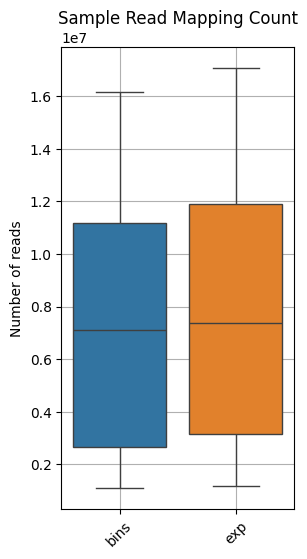

In [368]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 6))
sns.boxplot(data=df_read_mapping)
plt.xticks(rotation=45)
plt.title("Sample Read Mapping Count")
plt.ylabel("Number of reads")
plt.xlabel("")
#plt.yscale('log')
plt.grid(True)
plt.show()

In [355]:
len(bins & exp)

0

In [353]:
sample_to_mapping[sample_id].keys()

dict_keys(['bins', 'exp'])

In [341]:
len(sample_to_mapping['R1_A_D1_MG']['derep'])

310

In [344]:
len(sample_to_mapping['R1_A_D1_MG']['exp'])

1253

In [323]:
!ls /scratch/shared/CDM/salterns/reads/coverm/R1_A_D1_MG/bins_derep/

coverm-genome.R1_A_D1_MG_1.fastq.bam	    coverm.o	   coverm.stdout
coverm-genome.R1_A_D1_MG_1.fastq.bam.index  coverm.stderr


In [335]:
def get_genome_contig_read_mapping(sam_h):
    genome_contig_read_mapping = {}
    for read in tqdm(sam_h.fetch()):
        blocks = read.get_blocks()
        if len(blocks) != 0:
            genome_id, contig_id = read.reference_name.split('~')
            if genome_id not in genome_contig_read_mapping:
                genome_contig_read_mapping[genome_id] = {}
            if contig_id not in genome_contig_read_mapping[genome_id]:
                genome_contig_read_mapping[genome_id][contig_id] = set()
            genome_contig_read_mapping[genome_id][contig_id].add(read.qname)
    return genome_contig_read_mapping

In [334]:
sam_derep.close()

In [331]:
genome_contig_read_mapping

{'Salt_Pond_MetaG_R2_restored_DShore_MG_DASTool_bins_maxbin.037.contigs': {'NODE_863_length_28596_cov_2.44009': {'HISEQ15:203:C7P4WANXX:6:1207:3857:14590'}}}

In [ ]:
import pysam
from tqdm import tqdm
def get_reads_mapped(sam):
    reads_mapped = {}
    for read in tqdm(sam.fetch()):
        blocks = read.get_blocks()
        if len(blocks) != 0:
            if read.qname not in reads_mapped:
                reads_mapped[read.qname] = []
            reads_mapped[read.qname].append(read)
    return reads_mapped
sample_id = 'R1_A_D1_MG'


In [370]:
1


1

In [371]:
import pysam
import pymongo
mongo_client = pymongo.MongoClient('mongodb://sequoia.mcs.anl.gov:27017')
mongo_project = mongo_client['salterns']

In [372]:
for c_name in mongo_project.list_collection_names():
    if c_name.startswith('reads_'):
        c = mongo_project[c_name]
        print(c_name, c.estimated_document_count())

reads_R1_B_H2O_MG_bins 6903800
reads_R2A_A_H2O_MG_bins 18455286
reads_R1_A_D2_MG_bins 30676872
reads_R1_A_D1_MG 203928
reads_R1_B_D1_MG_bins 28011074
reads_R2A_B_D2_MG_bins 3109760
reads_R2_C_D1_MG_bins 21828656
reads_R1_B_D2_MG_bins 31427272
reads_R1_A_H2O_MG_bins 15843538
reads_R2_B_H2O_MG_bins 17355290
reads_R2A_A_D2_MG_bins 2833058
reads_R2A_B_D1_MG_bins 2179944
reads_R2_restored_C_black_MG_bins 8118600
reads_R1_A_D1_MG_bins 29957612
reads_R1_A_D2_MG 5228600
reads_R2A_A_D1_MG_bins 4459012
reads_R2A_B_H2O_MG_bins 2944700
reads_R2_C_H2O_MG_bins 23332766
